In [1]:
# Create the project folders
!mkdir -p etl-job-market-pipeline/{data/raw,src,sql,output}

In [2]:
from google.colab import files
uploaded = files.upload()

Saving etl-job-market-pipeline.zip to etl-job-market-pipeline.zip


In [3]:
!unzip -o etl-job-market-pipeline.zip

Archive:  etl-job-market-pipeline.zip
  inflating: etl-job-market-pipeline/generate_sample_data.py  
 extracting: etl-job-market-pipeline/requirements.txt  
  inflating: etl-job-market-pipeline/sql/analysis_queries.sql  
  inflating: etl-job-market-pipeline/src/transform.py  
  inflating: etl-job-market-pipeline/src/extract.py  
 extracting: etl-job-market-pipeline/src/__init__.py  
  inflating: etl-job-market-pipeline/src/pipeline.py  
  inflating: etl-job-market-pipeline/src/load.py  
  inflating: etl-job-market-pipeline/src/validate.py  
   creating: etl-job-market-pipeline/{data/
   creating: etl-job-market-pipeline/{data/raw,src,sql,output}/
  inflating: etl-job-market-pipeline/README.md  
 extracting: etl-job-market-pipeline/data/raw/.gitkeep  
 extracting: etl-job-market-pipeline/output/.gitkeep  


In [4]:
%cd etl-job-market-pipeline

/content/etl-job-market-pipeline


In [5]:
!python generate_sample_data.py

Generated 515 raw job postings at /content/etl-job-market-pipeline/data/raw/job_postings_raw.csv


In [6]:
!python src/pipeline.py

10:19:53 | INFO    | ============================================================
10:19:53 | INFO    | ETL PIPELINE STARTED
10:19:53 | INFO    | Timestamp: 2026-04-22 10:19:53
10:19:53 | INFO    | ============================================================
10:19:53 | INFO    | 
10:19:53 | INFO    | STEP 1: EXTRACT
10:19:53 | INFO    | ----------------------------------------
10:19:53 | INFO    | Extracting data from /content/etl-job-market-pipeline/data/raw/job_postings_raw.csv
10:19:53 | INFO    | Extracted 515 rows and 10 columns
10:19:53 | INFO    | Columns found: ['job_id', 'title', 'company', 'location', 'salary', 'experience_level', 'employment_type', 'skills_required', 'date_posted', 'description']
10:19:53 | INFO    | Null counts per column:
job_id               27
title                 0
company              42
location             83
salary              128
experience_level     69
employment_type      92
skills_required     160
date_posted         132
description          61

In [7]:
import pandas as pd
df = pd.read_csv("output/job_postings_clean.csv")
print(f"Clean rows: {len(df)}")
df.head(10)

Clean rows: 474


,job_id,title,company,location,salary,experience_level,employment_type,skills,skill_count,date_posted
0,JOB-0310,Platform Engineer,NaN,"Galway, Ireland",61379.0,Not Specified,Contract,"Kafka, Sql, Redis, Terraform, Spark, Gcp",6,2025-08-18
1,JOB-0499,Infrastructure Engineer,SAP,"Dublin, Ireland",74222.0,Senior,Contract,"React, Pandas, Etl, Linux, Git, Terraform, Spa...",8,yesterday
2,JOB-0087,Site Reliability Engineer,Amazon,"Dublin, Ireland (Hybrid)",NaN,Lead,Full-time,"Spark, Airflow, Gcp, Ci/Cd, Rust, Scala, Bash,...",8,08-08-2025
3,JOB-0289,Cloud Engineer,Workday,"Dublin, Ireland",63847.0,Mid,Full-time,NaN,0,05/09/2025
4,JOB-0265,Data Analyst,KPMG,NaN,62610.0,Mid,Full-time,"Azure, Python",2,yesterday
5,JOB-0407,Systems Engineer,Workday,Remote,55000.0,Mid,Full-time,NaN,0,yesterday
6,JOB-0350,Backend Engineer,Workday,Remote,67000.0,Senior,Full-time,NaN,0,01/05/2025
7,JOB-0121,Software Engineer,KPMG,"Dublin, Ireland",NaN,Lead,Not Specified,NaN,0,yesterday
8,JOB-0277,Data Engineer,KPMG,NaN,NaN,Junior,Full-time,"React, Redis, Linux, Pandas, Kafka, Spark",6,07-28-2025
9,JOB-0329,Data Engineer,Fidelity,"Dublin, Ireland",NaN,Senior,Contract,"Airflow, Git",2,NaN


In [8]:
# Top job titles after cleaning
df["title"].value_counts().head(10)

,count
title,
Data Engineer,90
Devops Engineer,44
Junior Data Engineer,34
Database Administrator,31
Cloud Engineer,29
Data Analyst,29
Ml Engineer,29
Senior Data Engineer,27
Full Stack Developer,25


In [9]:
# Average salary by experience level
df.groupby("experience_level")["salary"].mean().sort_values(ascending=False)

,salary
experience_level,
Not Specified,73120.320000
Junior,68366.000000
Mid,64075.527778
Lead,63959.117647
Senior,59233.687500


In [10]:
# CELL 1: Setup and load data
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [11]:
# Set a clean visual style
plt.rcParams['figure.facecolor'] = '#0a0a0a'
plt.rcParams['axes.facecolor'] = '#141414'
plt.rcParams['text.color'] = '#e8e8e8'
plt.rcParams['axes.labelcolor'] = '#e8e8e8'
plt.rcParams['xtick.color'] = '#888888'
plt.rcParams['ytick.color'] = '#888888'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

ACCENT = '#4ecdc4'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#ffe66d'
ACCENT4 = '#a8e6cf'

df = pd.read_csv("output/job_postings_clean.csv")
print(f"Loaded {len(df)} clean job postings")
print(f"Columns: {list(df.columns)}")

Loaded 474 clean job postings
Columns: ['job_id', 'title', 'company', 'location', 'salary', 'experience_level', 'employment_type', 'skills', 'skill_count', 'date_posted']


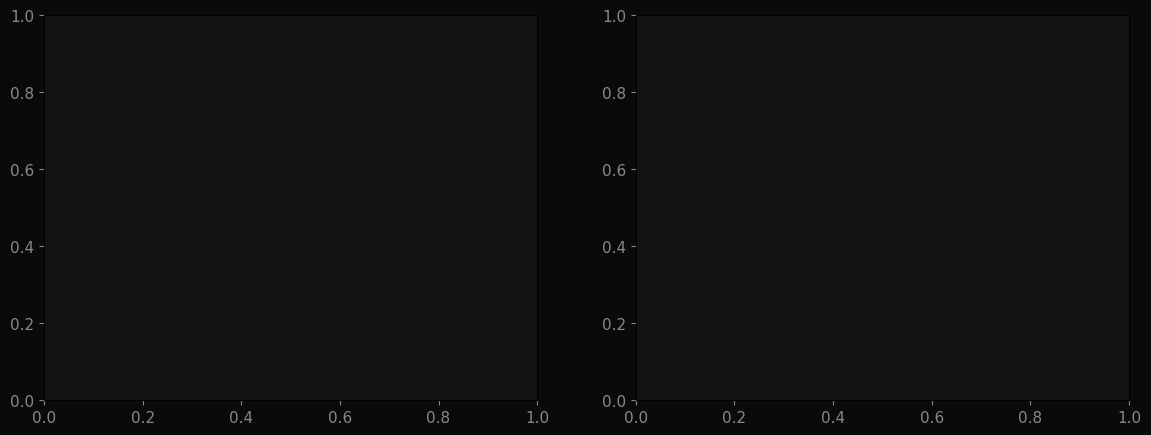

In [12]:
# CELL 2: Before vs After — Pipeline Impact
# ============================================================
raw_df = pd.read_csv("data/raw/job_postings_raw.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [13]:
# Raw data null counts
raw_nulls = raw_df.isnull().sum().sort_values(ascending=True)
axes[0].barh(raw_nulls.index, raw_nulls.values, color=ACCENT2, alpha=0.8)
axes[0].set_title('BEFORE: Null Values in Raw Data', fontsize=13, fontweight='bold', color=ACCENT2)
axes[0].set_xlabel('Number of Nulls')

Text(0.5, 4.444444444444452, 'Number of Nulls')

In [14]:
# Clean data null counts
clean_nulls = df.isnull().sum().sort_values(ascending=True)
axes[1].barh(clean_nulls.index, clean_nulls.values, color=ACCENT, alpha=0.8)
axes[1].set_title('AFTER: Null Values in Clean Data', fontsize=13, fontweight='bold', color=ACCENT)
axes[1].set_xlabel('Number of Nulls')

plt.suptitle('ETL Pipeline Impact — Data Quality Improvement', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/01_pipeline_impact.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print(f"\nRaw rows: {len(raw_df)} → Clean rows: {len(df)} ({len(raw_df) - len(df)} removed)")

<Figure size 640x480 with 0 Axes>


Raw rows: 515 → Clean rows: 474 (41 removed)


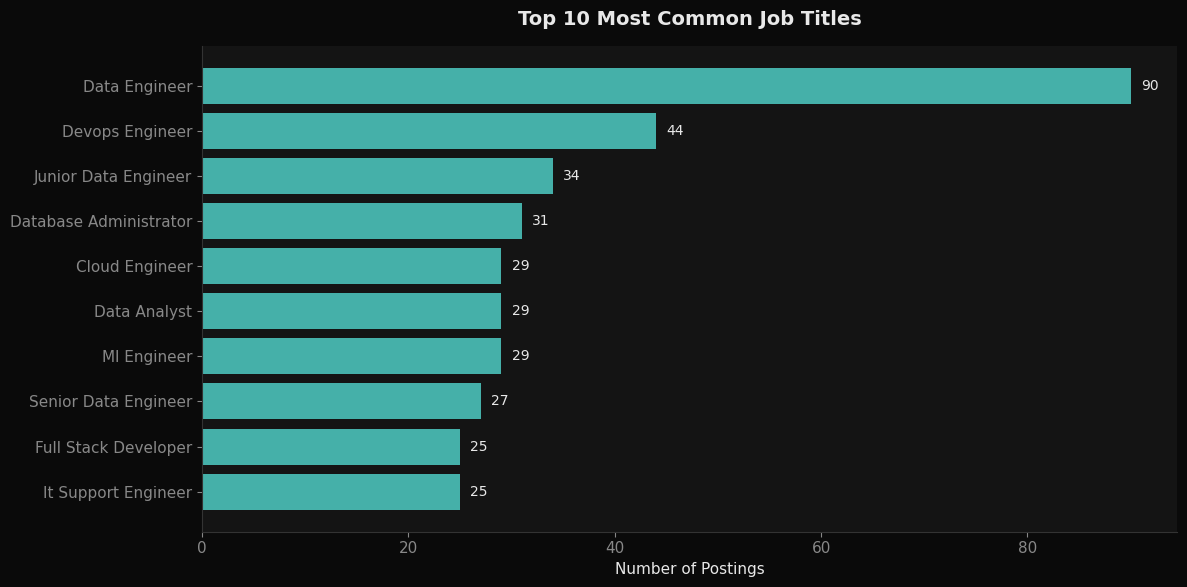

In [15]:
# CELL 3: Top 10 Job Titles
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

title_counts = df['title'].value_counts().head(10)
bars = ax.barh(title_counts.index[::-1], title_counts.values[::-1], color=ACCENT, alpha=0.85)

# Add value labels on bars
for bar, val in zip(bars, title_counts.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, color='#e8e8e8')

ax.set_title('Top 10 Most Common Job Titles', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Postings')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#333')
ax.spines['left'].set_color('#333')

plt.tight_layout()
plt.savefig('output/02_top_titles.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

/tmp/ipykernel_3933/1931701482.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(exp_salaries, labels=exp_order, patch_artist=True, widths=0.6,


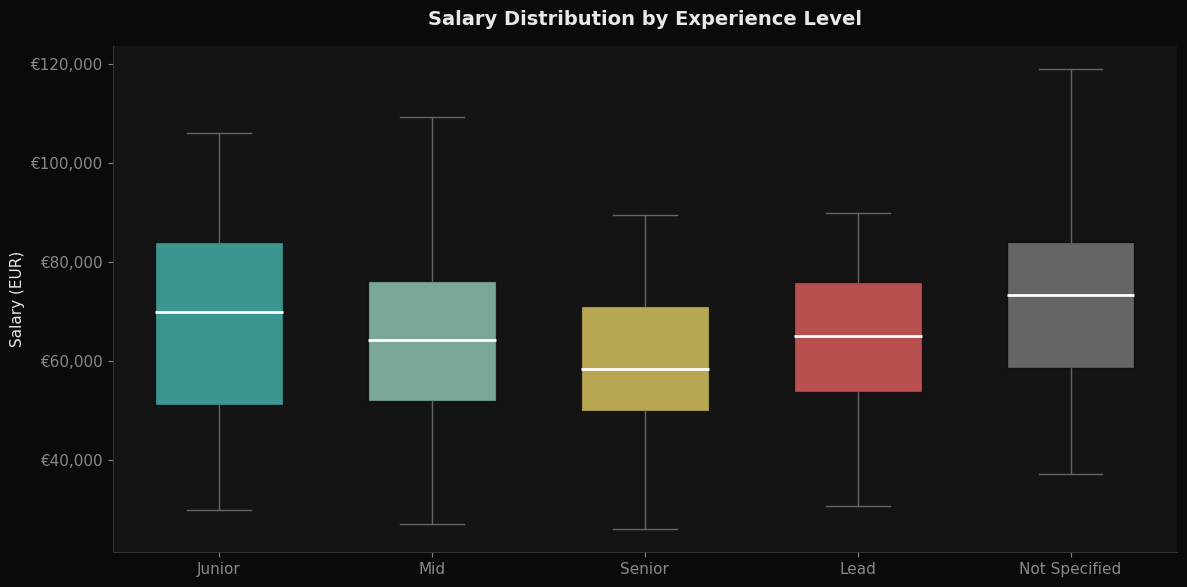

In [16]:
# CELL 4: Salary Distribution by Experience Level
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

salary_data = df[df['salary'].notna()]
exp_order = ['Junior', 'Mid', 'Senior', 'Lead', 'Not Specified']
exp_salaries = [salary_data[salary_data['experience_level'] == e]['salary'].values for e in exp_order]

colors_box = [ACCENT, ACCENT4, ACCENT3, ACCENT2, '#888888']

bp = ax.boxplot(exp_salaries, labels=exp_order, patch_artist=True, widths=0.6,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#666'),
                capprops=dict(color='#666'),
                flierprops=dict(marker='o', markerfacecolor='#666', markersize=4, alpha=0.5))

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Salary Distribution by Experience Level', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Salary (EUR)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#333')
ax.spines['left'].set_color('#333')

plt.tight_layout()
plt.savefig('output/03_salary_by_experience.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

In [17]:
# Print the averages
print("\nAverage Salary by Experience Level:")
for e in exp_order:
    avg = salary_data[salary_data['experience_level'] == e]['salary'].mean()
    count = len(salary_data[salary_data['experience_level'] == e])
    if count > 0:
        print(f"  {e}: €{avg:,.0f} ({count} postings with salary data)")


Average Salary by Experience Level:
  Junior: €68,366 (31 postings with salary data)
  Mid: €64,076 (36 postings with salary data)
  Senior: €59,234 (32 postings with salary data)
  Lead: €63,959 (17 postings with salary data)
  Not Specified: €73,120 (25 postings with salary data)


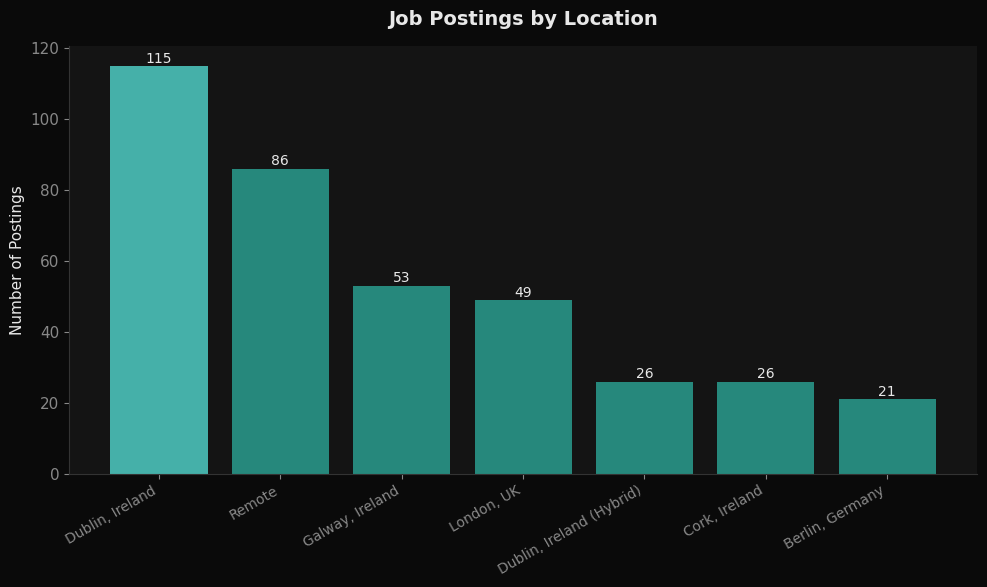

In [18]:
# CELL 5: Jobs by Location
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

location_counts = df['location'].value_counts().head(8)
colors_loc = [ACCENT if i == 0 else '#2a9d8f' for i in range(len(location_counts))]

bars = ax.bar(range(len(location_counts)), location_counts.values, color=colors_loc, alpha=0.85)

ax.set_xticks(range(len(location_counts)))
ax.set_xticklabels(location_counts.index, rotation=30, ha='right', fontsize=10)
ax.set_title('Job Postings by Location', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Postings')

# Add value labels on bars
for bar, val in zip(bars, location_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=10, color='#e8e8e8')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#333')
ax.spines['left'].set_color('#333')

plt.tight_layout()
plt.savefig('output/04_jobs_by_location.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()


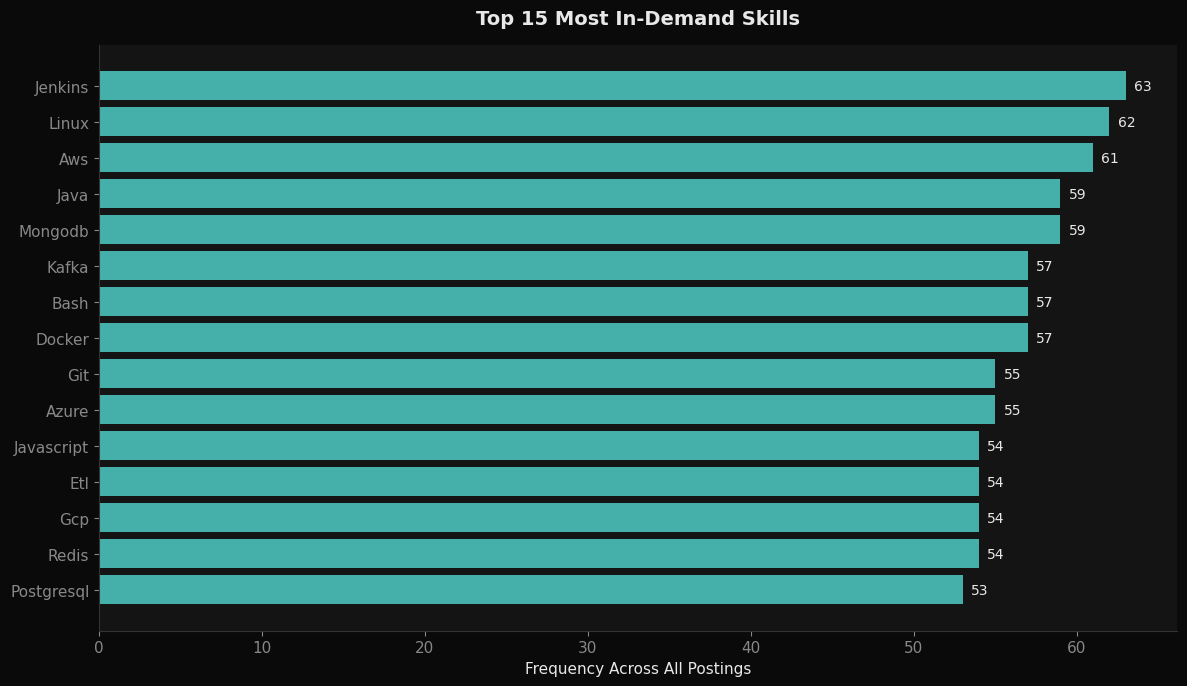

In [19]:
# CELL 6: Top 15 Most In-Demand Skills
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

# Split all skills and count them
all_skills = df['skills'].dropna().str.split(', ').explode()
skill_counts = all_skills.value_counts().head(15)

bars = ax.barh(skill_counts.index[::-1], skill_counts.values[::-1],
               color=ACCENT, alpha=0.85)

for bar, val in zip(bars, skill_counts.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, color='#e8e8e8')

ax.set_title('Top 15 Most In-Demand Skills', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Frequency Across All Postings')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#333')
ax.spines['left'].set_color('#333')

plt.tight_layout()
plt.savefig('output/05_top_skills.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

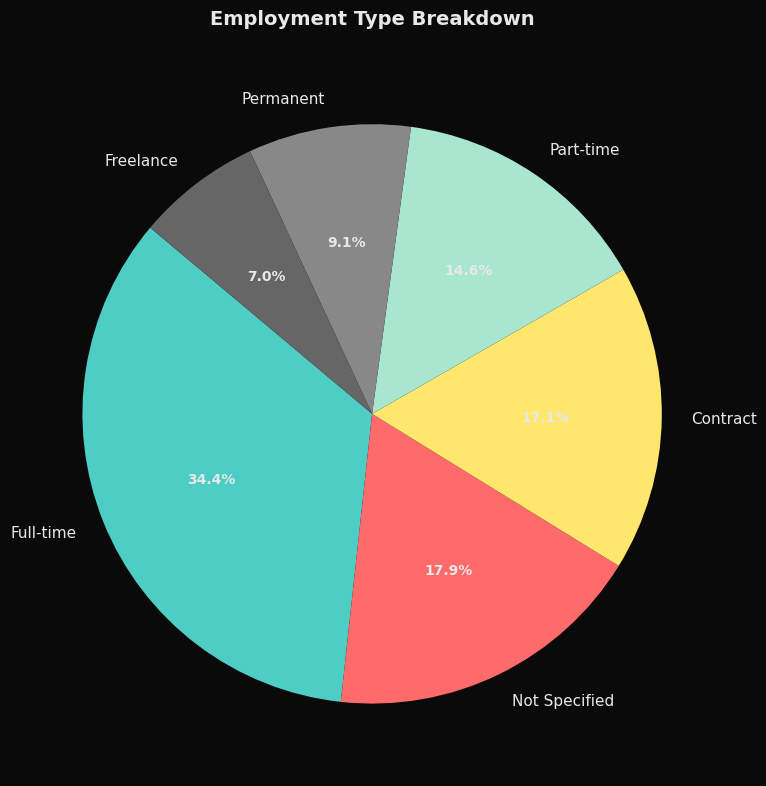

In [20]:
# CELL 7: Employment Type Breakdown (Pie Chart)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

emp_counts = df['employment_type'].value_counts()
colors_pie = [ACCENT, ACCENT2, ACCENT3, ACCENT4, '#888888', '#666666']

wedges, texts, autotexts = ax.pie(
    emp_counts.values,
    labels=emp_counts.index,
    colors=colors_pie[:len(emp_counts)],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11, 'color': '#e8e8e8'}
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Employment Type Breakdown', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('output/06_employment_types.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

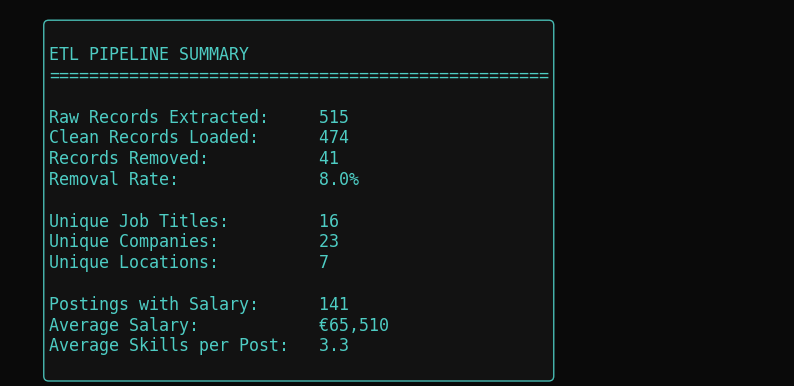


All visualisations saved to output/ folder!


In [23]:
# CELL 8: Pipeline Summary Dashboard
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

summary_text = f"""
ETL PIPELINE SUMMARY
{'='*50}

Raw Records Extracted:     {len(raw_df)}
Clean Records Loaded:      {len(df)}
Records Removed:           {len(raw_df) - len(df)}
Removal Rate:              {(len(raw_df) - len(df)) / len(raw_df) * 100:.1f}%

Unique Job Titles:         {df['title'].nunique()}
Unique Companies:          {df['company'].nunique()}
Unique Locations:          {df['location'].nunique()}

Postings with Salary:      {df['salary'].notna().sum()}
Average Salary:            €{df['salary'].mean():,.0f}
Average Skills per Post:   {df['skill_count'].mean():.1f}
"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=12, fontfamily='monospace', color=ACCENT,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#141414', edgecolor=ACCENT, alpha=0.9))

plt.savefig('output/07_summary.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("\nAll visualisations saved to output/ folder!")

In [24]:
!zip -r /content/etl-project-complete.zip /content/etl-job-market-pipeline/
from google.colab import files
files.download('/content/etl-project-complete.zip')

  adding: content/etl-job-market-pipeline/ (stored 0%)
  adding: content/etl-job-market-pipeline/{data/ (stored 0%)
  adding: content/etl-job-market-pipeline/{data/raw,src,sql,output}/ (stored 0%)
  adding: content/etl-job-market-pipeline/data/ (stored 0%)
  adding: content/etl-job-market-pipeline/data/raw/ (stored 0%)
  adding: content/etl-job-market-pipeline/data/raw/.gitkeep (stored 0%)
  adding: content/etl-job-market-pipeline/data/raw/job_postings_raw.csv (deflated 83%)
  adding: content/etl-job-market-pipeline/README.md (deflated 57%)
  adding: content/etl-job-market-pipeline/requirements.txt (stored 0%)
  adding: content/etl-job-market-pipeline/generate_sample_data.py (deflated 59%)
  adding: content/etl-job-market-pipeline/output/ (stored 0%)
  adding: content/etl-job-market-pipeline/output/06_employment_types.png (deflated 9%)
  adding: content/etl-job-market-pipeline/output/.gitkeep (stored 0%)
  adding: content/etl-job-market-pipeline/output/03_salary_by_experience.png (defl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>